In [248]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use("seaborn-v0_8-whitegrid")

DB_FILE = Path("../data/emi_nav.db")

# Zeitliche Aggregation: pro Beacon ein RSSI-Median je Zeitfenster
WINDOW_MS = 1000

# Log-Distance-Path-Loss-Modell:
# RSSI(d) = RSSI_AT_1M - 10 * N * log10(d)
RSSI_AT_1M = -59.0
PATH_LOSS_N = 2.5

# Gebäudeskalierung aus map_generation:
# 132.5 m entsprechen 7820 px
PIXEL_TO_METER = 0.2

In [249]:
# (x_px, y_px, floor)
# floor: 1 = Erdgeschoss, 0 = 1. Obergeschoss
beacons_px = {
    "arrive_emi1": (370.0, 47.0, 1),
    "arrive_emi2": (445.0, 40.0, 1),
    "arrive_emi3": (588.0, 20.0, 1),
    "arrive_emi4": (590.0, 20.0, 0),
    "arrive_emi8": (370.0, 50.0, 0),
    "arrive_emi10": (510.0, 40.0, 0),
}

beacons = pd.DataFrame.from_dict(
    beacons_px,
    orient="index",
    columns=["x_px", "y_px", "floor"]
).rename_axis("beacon_name").reset_index()

beacons["x_m"] = beacons["x_px"] * PIXEL_TO_METER
beacons["y_m"] = beacons["y_px"] * PIXEL_TO_METER

beacons

,beacon_name,x_px,y_px,floor,x_m,y_m
0,arrive_emi1,370.0,47.0,1,74.0,9.4
1,arrive_emi2,445.0,40.0,1,89.0,8.0
2,arrive_emi3,588.0,20.0,1,117.6,4.0
3,arrive_emi4,590.0,20.0,0,118.0,4.0
4,arrive_emi8,370.0,50.0,0,74.0,10.0
5,arrive_emi10,510.0,40.0,0,102.0,8.0


In [250]:
if not DB_FILE.exists():
    raise FileNotFoundError(
        f"'{DB_FILE}' wurde nicht gefunden. "
        "Lege die Datenbank in denselben Ordner wie das Notebook."
    )

conn = sqlite3.connect(DB_FILE)

runs = pd.read_sql_query(
    """
    SELECT run_id, filename, date, notes
    FROM runs
    ORDER BY date, run_id
    """,
    conn
)

ble_raw = pd.read_sql_query(
    """
    SELECT
        run_id,
        timestamp_ms,
        beacon_name,
        address,
        rssi
    FROM ble_rssi
    WHERE REPLACE(address, ':', '') != 'FBADD6D492CE'
    ORDER BY run_id, timestamp_ms
    """,
    conn
)

groundtruth = pd.read_sql_query(
        """
        SELECT
            run_id,
            tuer_id,
            timestamp_ms
        FROM groundtruth
        ORDER BY timestamp_ms
        """,
        conn,
    )

runs
print("Anzahl BLE-Rohmessungen:", len(ble_raw))
print("\nMessungen je Run:")
display(ble_raw.groupby("run_id").size().rename("n_measurements").to_frame())

print("\nBeacons je Run:")
display(
    ble_raw.groupby("run_id")["beacon_name"]
    .agg(lambda values: sorted(values.dropna().unique()))
    .rename("beacons")
    .to_frame()
)

Anzahl BLE-Rohmessungen: 3683

Messungen je Run:


,n_measurements
run_id,
R1,504
R2,1436
R3,1743



Beacons je Run:


,beacons
run_id,
R1,"[arrive_emi1, arrive_emi10, arrive_emi2, arriv..."
R2,"[arrive_emi1, arrive_emi10, arrive_emi2, arriv..."
R3,"[arrive_emi1, arrive_emi10, arrive_emi2, arriv..."


In [251]:
ble = ble_raw.copy()

ble["rssi"] = pd.to_numeric(ble["rssi"], errors="coerce")
ble["timestamp_ms"] = pd.to_numeric(ble["timestamp_ms"], errors="coerce")

ble = (
    ble
    .dropna(subset=["run_id", "timestamp_ms", "beacon_name", "rssi"])
    .query("rssi < 0")
    .copy()
)

ble["window_ms"] = (
    ble["timestamp_ms"] // WINDOW_MS
).astype("int64") * WINDOW_MS

rssi_windows = (
    ble
    .pivot_table(
        index=["run_id", "window_ms"],
        columns="beacon_name",
        values="rssi",
        aggfunc="median"
    )
    .sort_index()
    .reset_index()
)

rssi_windows["time_readable"] = pd.to_datetime(
    rssi_windows["window_ms"],
    unit="ms",
    utc=True
).dt.tz_convert("Europe/Berlin")

print("Beacons in der Datenbank:")
print(rssi_windows.columns.drop(
            ["run_id", "window_ms", "time_readable"]
        ).tolist()
)

rssi_windows.head()

Beacons in der Datenbank:
['arrive_emi1', 'arrive_emi10', 'arrive_emi2', 'arrive_emi3', 'arrive_emi4', 'arrive_emi8']


beacon_name,run_id,window_ms,arrive_emi1,arrive_emi10,arrive_emi2,arrive_emi3,arrive_emi4,arrive_emi8,time_readable
0,R1,1781612173000,NaN,NaN,NaN,-98.0,-66.5,NaN,2026-06-16 14:16:13+02:00
1,R1,1781612174000,NaN,NaN,NaN,-89.5,-74.0,NaN,2026-06-16 14:16:14+02:00
2,R1,1781612175000,NaN,NaN,NaN,-93.0,-82.0,NaN,2026-06-16 14:16:15+02:00
3,R1,1781612176000,NaN,NaN,NaN,-96.0,-80.0,NaN,2026-06-16 14:16:16+02:00
4,R1,1781612177000,NaN,NaN,NaN,-91.0,-79.0,NaN,2026-06-16 14:16:17+02:00


In [252]:
def rssi_to_distance(rssi, rssi_at_1m=RSSI_AT_1M, path_loss_n=PATH_LOSS_N):
    """
    Wandelt RSSI in eine geschätzte Distanz in Metern um.

    RSSI(d) = RSSI_AT_1M - 10 * n * log10(d)
    """
    rssi = np.asarray(rssi, dtype=float)
    return 10 ** ((rssi_at_1m - rssi) / (10 * path_loss_n))


def distance_to_rssi(distance_m, rssi_at_1m=RSSI_AT_1M, path_loss_n=PATH_LOSS_N):
    """
    Gegenrichtung zum Testen des Modells.
    """
    distance_m = np.asarray(distance_m, dtype=float)
    return rssi_at_1m - 10 * path_loss_n * np.log10(distance_m)


# Sanity Check wie in der Übung:
print("RSSI bei 1 m:", distance_to_rssi(1.0), "dBm")
print("Distanz für RSSI_AT_1M:", rssi_to_distance(RSSI_AT_1M), "m")

RSSI bei 1 m: -59.0 dBm
Distanz für RSSI_AT_1M: 1.0 m


In [253]:
def multilaterate_least_squares(anchors_m, distances_m):
    """
    Schätzt eine 2D-Position aus N >= 3 Ankern und Distanzschätzungen.

    Verwendet die linearisierte Form der Kreisgleichungen und Least Squares,
    analog zu multilateration_exercise.ipynb.
    """
    anchors_m = np.asarray(anchors_m, dtype=float)
    distances_m = np.asarray(distances_m, dtype=float)

    if anchors_m.ndim != 2 or anchors_m.shape[1] != 2:
        raise ValueError("anchors_m muss die Form (N, 2) haben.")

    if len(anchors_m) != len(distances_m):
        raise ValueError("Für jeden Anker wird genau eine Distanz benötigt.")

    if len(anchors_m) < 3:
        raise ValueError("Mindestens drei Anker sind erforderlich.")

    x1, y1 = anchors_m[0]
    d1 = distances_m[0]

    A = []
    b = []

    for (xi, yi), di in zip(anchors_m[1:], distances_m[1:]):
        A.append([xi - x1, yi - y1])
        b.append(
            0.5 * (
                d1**2
                - di**2
                + xi**2
                - x1**2
                + yi**2
                - y1**2
            )
        )

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)

    position_m, residuals, rank, singular_values = np.linalg.lstsq(
        A, b, rcond=None
    )

    return position_m, residuals, rank, singular_values

In [254]:
def circle_residuals(position_m, anchors_m, measured_distances_m):
    """
    Abweichung zwischen modellierter und gemessener Entfernung je Beacon.

    residual_i = ||position - anchor_i|| - measured_distance_i
    """
    predicted_distances_m = np.linalg.norm(
        anchors_m - position_m,
        axis=1
    )

    return predicted_distances_m - measured_distances_m

In [255]:
known_beacon_names = set(beacons["beacon_name"])

beacon_lookup = (
    beacons
    .set_index("beacon_name")[["x_m", "y_m", "floor"]]
    .to_dict(orient="index")
)

estimates = []

# Robust: funktioniert bei MultiIndex UND bei normalen Spalten
has_multiindex = (
    isinstance(rssi_windows.index, pd.MultiIndex)
    and {"run_id", "window_ms"}.issubset(rssi_windows.index.names)
)

for index, data_row in rssi_windows.iterrows():

    if has_multiindex:
        run_id, window_ms = index
        row = data_row.copy()
    else:
        run_id = data_row["run_id"]
        window_ms = data_row["window_ms"]

        # Metadaten entfernen: Übrig bleiben nur Beacon-RSSI-Werte
        row = data_row.drop(
            labels=["run_id", "window_ms"],
            errors="ignore"
        )

    # Fehlende RSSI-Messungen entfernen
    row = row.dropna()

    # Nur bekannte Beacons verwenden
    row = row[row.index.isin(known_beacon_names)]

    # Beacons ohne echte Koordinate entfernen, z. B. (0, 0)
    row = row[
        [
            beacon_name
            for beacon_name in row.index
            if (
                beacon_lookup[beacon_name]["x_m"] != 0.0
                or beacon_lookup[beacon_name]["y_m"] != 0.0
            )
        ]
    ]

    # 2D-Multilateration braucht mindestens drei Beacons
    if len(row) < 3:
        continue

    beacon_names = row.index.to_list()
    rssis = row.to_numpy(dtype=float)

    anchors_m = np.array([
        [
            beacon_lookup[beacon_name]["x_m"],
            beacon_lookup[beacon_name]["y_m"]
        ]
        for beacon_name in beacon_names
    ])

    distances_m = rssi_to_distance(rssis)

    try:
        position_m, _, rank, _ = multilaterate_least_squares(
            anchors_m,
            distances_m
        )
    except np.linalg.LinAlgError:
        continue

    # Rang 2 bedeutet: Die Beacon-Geometrie erlaubt eine 2D-Schätzung
    if rank < 2:
        continue

    residuals_m = circle_residuals(
        position_m,
        anchors_m,
        distances_m
    )

    estimates.append({
        "run_id": run_id,
        "timestamp_ms": int(window_ms),
        "n_beacons": len(beacon_names),
        "beacons_used": ", ".join(beacon_names),
        "x_m": position_m[0],
        "y_m": position_m[1],
        "rmse_circle_m": np.sqrt(np.mean(residuals_m ** 2)),
        "mae_circle_m": np.mean(np.abs(residuals_m)),
        "max_abs_residual_m": np.max(np.abs(residuals_m)),
    })

positions = pd.DataFrame(estimates)

# Erst prüfen, bevor Spalten aus positions verwendet werden
if positions.empty:
    raise RuntimeError(
        "Keine Positionen berechnet. Prüfe Beacon-Namen, "
        "Beacon-Koordinaten und ob mindestens drei Beacons "
        "gleichzeitig gemessen wurden."
    )

# Zeitstempel als echtes datetime-Objekt: gut zum Sortieren/Filtern
positions["timestamp"] = (
    pd.to_datetime(
        positions["timestamp_ms"],
        unit="ms",
        utc=True
    )
    .dt.tz_convert("Europe/Berlin")
)

# Gut lesbare Darstellung für Tabellen und Ausgaben
positions["time_readable"] = positions["timestamp"].dt.strftime(
    "%d.%m.%Y %H:%M:%S"
)

# Meter zurück in Pixelkoordinaten der Karte
positions["x_px"] = positions["x_m"] / PIXEL_TO_METER
positions["y_px"] = positions["y_m"] / PIXEL_TO_METER

positions = positions.sort_values(
    ["run_id", "timestamp_ms"]
).reset_index(drop=True)

positions[
    [
        "run_id",
        "timestamp_ms",
        "timestamp",
        "time_readable",
        "n_beacons",
        "x_m",
        "y_m",
        "rmse_circle_m"
    ]
].head(10)

,run_id,timestamp_ms,timestamp,time_readable,n_beacons,x_m,y_m,rmse_circle_m
0,R1,1781612180000,2026-06-16 14:16:20+02:00,16.06.2026 14:16:20,3,466.658119,1298.436288,1322.361621
1,R1,1781612182000,2026-06-16 14:16:22+02:00,16.06.2026 14:16:22,3,395.510569,1141.714067,1162.669665
2,R1,1781612183000,2026-06-16 14:16:23+02:00,16.06.2026 14:16:23,3,323.624968,837.821627,848.880727
3,R1,1781612186000,2026-06-16 14:16:26+02:00,16.06.2026 14:16:26,3,311.206845,798.180899,807.901102
4,R1,1781612187000,2026-06-16 14:16:27+02:00,16.06.2026 14:16:27,3,503.078056,1568.675809,1600.419281
5,R1,1781612188000,2026-06-16 14:16:28+02:00,16.06.2026 14:16:28,3,1686.751255,6266.327508,6434.166599
6,R1,1781612189000,2026-06-16 14:16:29+02:00,16.06.2026 14:16:29,4,152.286508,273.584914,244.452948
7,R1,1781612191000,2026-06-16 14:16:31+02:00,16.06.2026 14:16:31,4,153.847996,230.576563,207.463558
8,R1,1781612192000,2026-06-16 14:16:32+02:00,16.06.2026 14:16:32,3,81.380063,-77.485404,73.998464
9,R1,1781612193000,2026-06-16 14:16:33+02:00,16.06.2026 14:16:33,3,41.707967,-186.672137,185.527787


In [256]:
run_summary = (
    positions
    .groupby("run_id")
    .agg(
        n_positions=("timestamp_ms", "size"),
        median_beacons=("n_beacons", "median"),
        mean_beacons=("n_beacons", "mean"),
        median_rmse_m=("rmse_circle_m", "median"),
        mean_rmse_m=("rmse_circle_m", "mean"),
        p90_rmse_m=("rmse_circle_m", lambda x: x.quantile(0.90)),
        median_mae_m=("mae_circle_m", "median"),
    )
    .round(3)
    .sort_index()
)

run_summary

beacon_availability = (
    ble
    .groupby(["run_id", "beacon_name"])
    .agg(
        n_measurements=("rssi", "size"),
        median_rssi=("rssi", "median"),
        mean_rssi=("rssi", "mean"),
        std_rssi=("rssi", "std")
    )
    .round(2)
    .sort_index()
)

beacon_availability

n_measurements  median_rssi  mean_rssi  std_rssi
run_id beacon_name                                                   
R1     arrive_emi1               16        -96.5     -95.12      4.10
       arrive_emi10             142        -86.0     -85.38      7.68
       arrive_emi2               77        -87.0     -86.66      7.05
       arrive_emi3               55        -91.0     -91.25      3.97
       arrive_emi4              141        -79.0     -80.62     10.33
       arrive_emi8               73        -83.0     -84.37      7.40
R2     arrive_emi1              203        -85.0     -84.49      7.81
       arrive_emi10             225        -85.0     -84.88      9.46
       arrive_emi2              170        -88.0     -85.61      9.34
       arrive_emi3              324        -84.0     -83.74      8.75
       arrive_emi4              321        -84.0     -82.78      9.73
       arrive_emi8              192        -86.0     -85.72      7.52
R3     arrive_emi1              151        -84.0     -85.45      5.82
       arrive_emi10             354        -87.0     -86.87      8.11
       arrive_emi2              201        -87.0     -87.35      6.16
       arrive_emi3              421        -88.0     -86.78      8.11
       arrive_emi4              441        -83.0     -82.67      9.52
       arrive_emi8              175        -86.0     -85.67      7.28

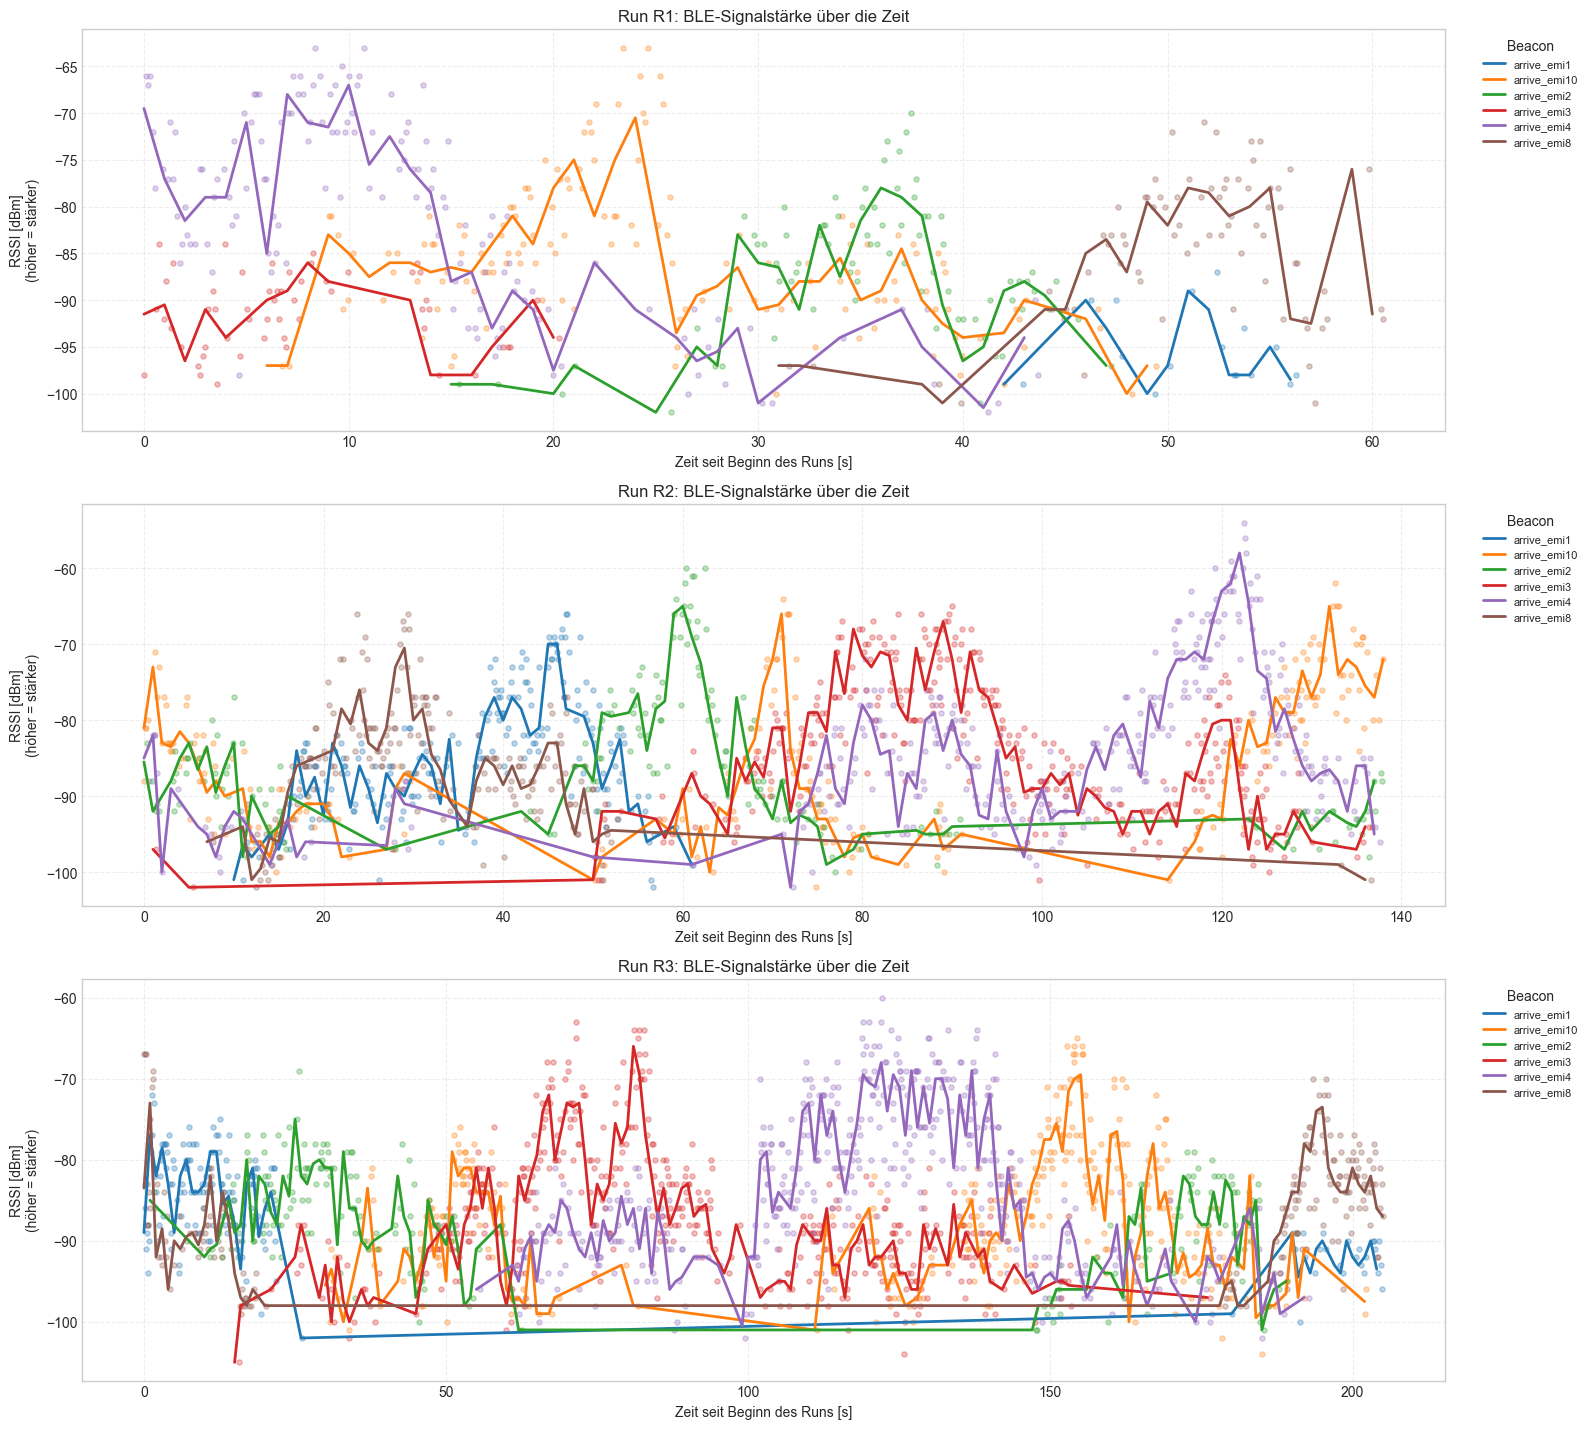

In [257]:
# Nur Beacons verwenden, für die es auch hinterlegte Koordinaten gibt
plot_data = ble.loc[
    ble["beacon_name"].isin(beacon_lookup.keys()),
    ["run_id", "timestamp_ms", "beacon_name", "rssi"]
].copy()

# Zeit relativ zum Beginn jedes Runs berechnen
plot_data["time_s"] = (
    plot_data["timestamp_ms"]
    - plot_data.groupby("run_id")["timestamp_ms"].transform("min")
) / 1000

plot_data = plot_data.sort_values(["run_id", "timestamp_ms"])

run_ids = sorted(plot_data["run_id"].unique())
n_runs = len(run_ids)

fig, axes = plt.subplots(
    n_runs,
    1,
    figsize=(16, 4.8 * n_runs),
    sharex=False,
    squeeze=False
)

for ax, run_id in zip(axes.ravel(), run_ids):
    run_data = plot_data.loc[plot_data["run_id"].eq(run_id)]

    for beacon_name, group in run_data.groupby("beacon_name", sort=True):
        # Einzelmessungen: zeigen das tatsächliche RSSI-Rauschen
        ax.scatter(
            group["time_s"],
            group["rssi"],
            s=14,
            alpha=0.30
        )

        # Ein Median pro Sekunde: zeigt den verständlichen Signaltrend
        smooth = (
            group.assign(time_bin=group["time_s"].astype(int))
            .groupby("time_bin", as_index=False)["rssi"]
            .median()
        )

        ax.plot(
            smooth["time_bin"],
            smooth["rssi"],
            linewidth=2,
            label=beacon_name
        )

    ax.set_title(f"Run {run_id}: BLE-Signalstärke über die Zeit")
    ax.set_xlabel("Zeit seit Beginn des Runs [s]")
    ax.set_ylabel("RSSI [dBm]\n(höher = stärker)")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(
        title="Beacon",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )

fig.tight_layout()
plt.show()

,run_id,tuer_id,timestamp_ms,time_s
0,R1,H01,1781612164000,0.0
1,R1,H02,1781612171000,7.0
2,R1,T022,1781612192000,28.0
3,R1,H03,1781612206000,42.0
4,R2,H03,1781614938000,0.0
5,R2,H13,1781614972000,34.0
6,R2,H12,1781614998000,60.0
7,R2,H11,1781615013000,75.0
8,R2,H01,1781615036000,98.0
9,R2,H02,1781615043000,105.0


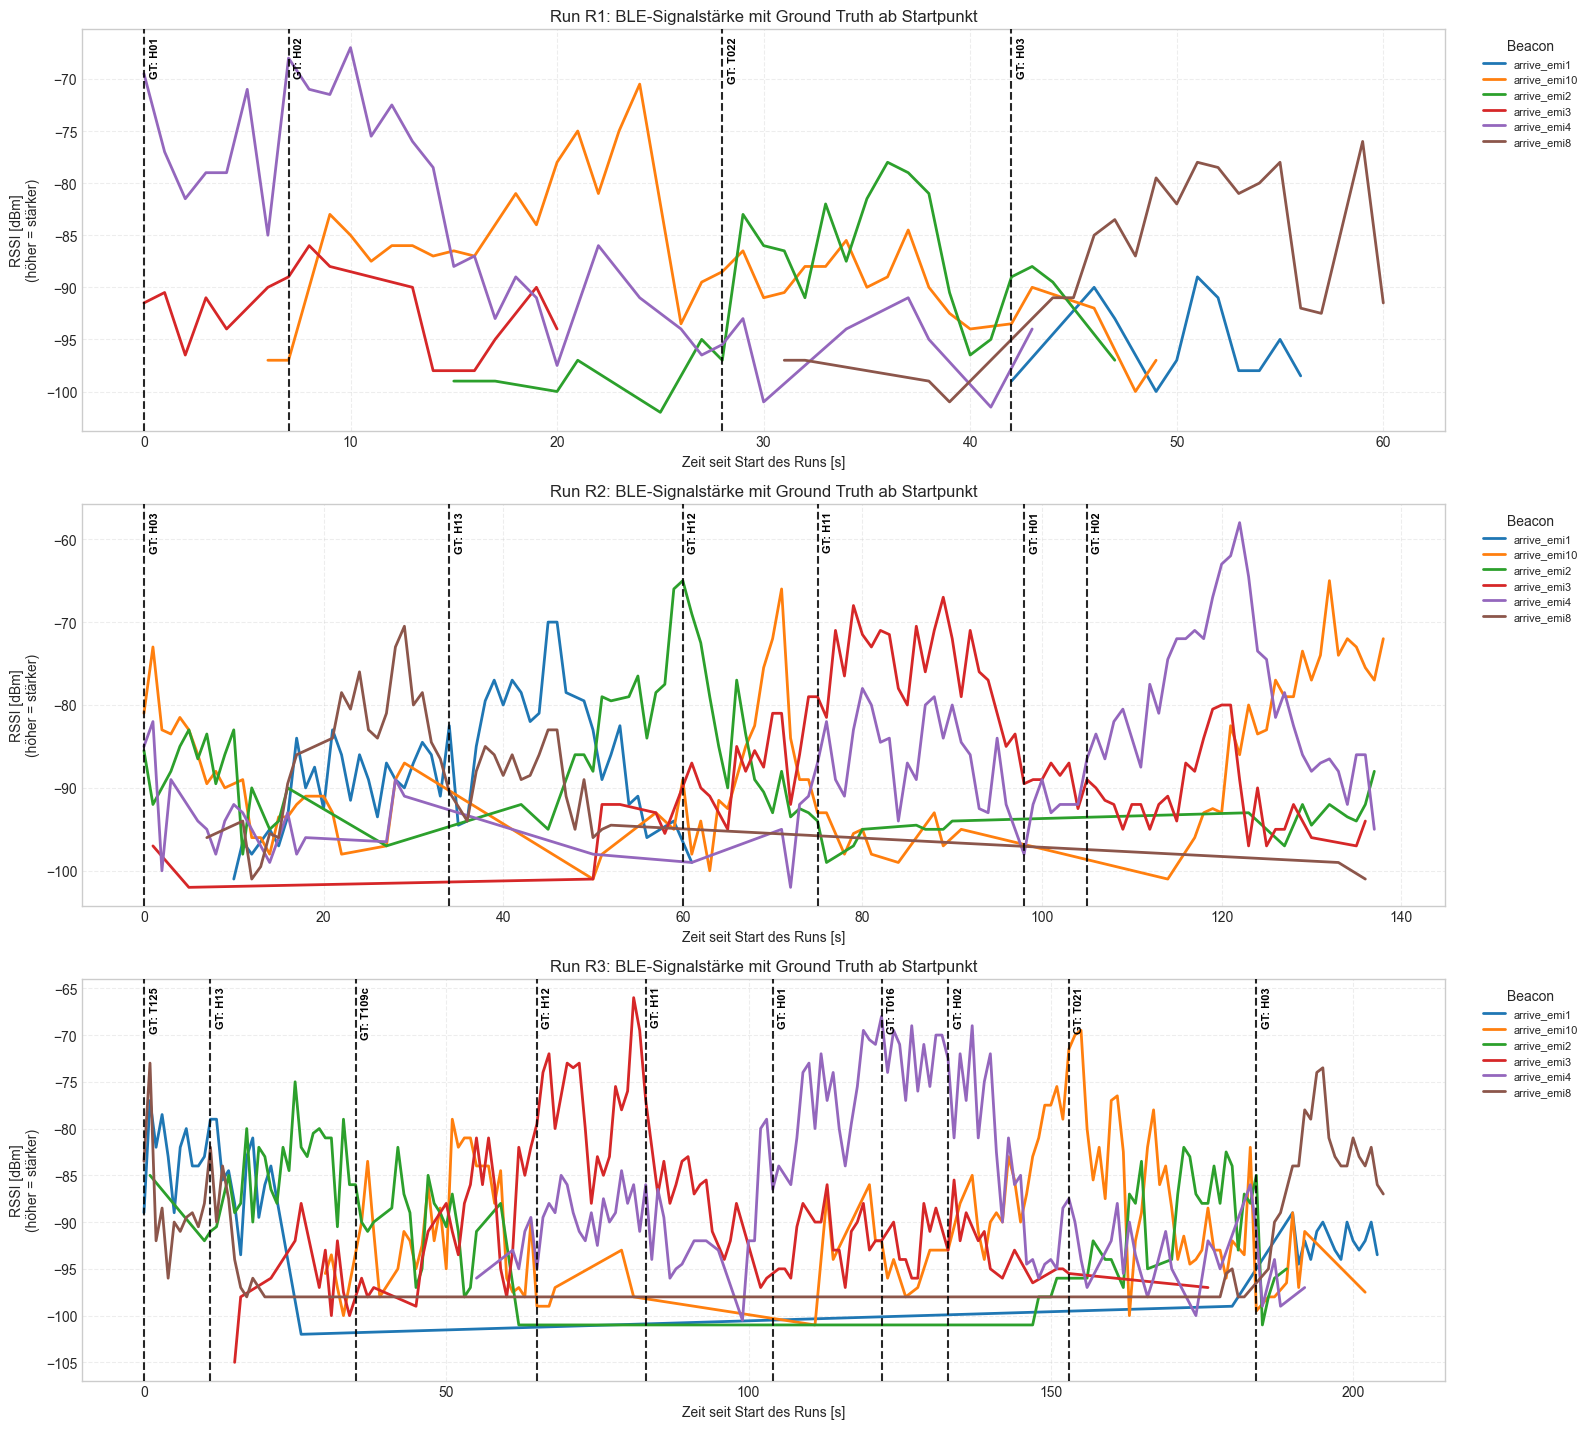

In [ ]:
# ------------------------------------------------------------
# 1. BLE-Daten vorbereiten
# ------------------------------------------------------------
plot_data = ble.loc[
    ble["beacon_name"].isin(beacon_lookup.keys()),
    ["run_id", "timestamp_ms", "beacon_name", "rssi"]
].copy()

plot_data["timestamp_ms"] = pd.to_numeric(
    plot_data["timestamp_ms"],
    errors="coerce"
)
plot_data["rssi"] = pd.to_numeric(
    plot_data["rssi"],
    errors="coerce"
)

plot_data = plot_data.dropna(
    subset=["run_id", "timestamp_ms", "beacon_name", "rssi"]
)

plot_data = plot_data.sort_values(["run_id", "timestamp_ms"])

# BLE: Zeit ab erstem BLE-Wert im jeweiligen Run
plot_data["time_s"] = (
    plot_data["timestamp_ms"]
    - plot_data.groupby("run_id")["timestamp_ms"].transform("min")
) / 1000


# ------------------------------------------------------------
# 2. Ground Truth vorbereiten
# ------------------------------------------------------------
groundtruth_plot = groundtruth.loc[
    groundtruth["run_id"].isin(plot_data["run_id"].unique()),
    ["run_id", "tuer_id", "timestamp_ms"]
].copy()

groundtruth_plot["timestamp_ms"] = pd.to_numeric(
    groundtruth_plot["timestamp_ms"],
    errors="coerce"
)

groundtruth_plot = groundtruth_plot.dropna(
    subset=["run_id", "tuer_id", "timestamp_ms"]
).sort_values(["run_id", "timestamp_ms"])

# Ground Truth: Zeit ab erstem GT-Wert im jeweiligen Run
groundtruth_plot["time_s"] = (
    groundtruth_plot["timestamp_ms"]
    - groundtruth_plot.groupby("run_id")["timestamp_ms"].transform("min")
) / 1000


# Optional: Kontrollausgabe
display(
    groundtruth_plot[
        ["run_id", "tuer_id", "timestamp_ms", "time_s"]
    ]
)


# ------------------------------------------------------------
# 3. Timeline je Run
# ------------------------------------------------------------
run_ids = sorted(plot_data["run_id"].unique())
n_runs = len(run_ids)

fig, axes = plt.subplots(
    n_runs,
    1,
    figsize=(16, 4.8 * n_runs),
    sharex=False,
    squeeze=False
)

for ax, run_id in zip(axes.ravel(), run_ids):
    run_data = plot_data.loc[plot_data["run_id"].eq(run_id)]
    run_groundtruth = groundtruth_plot.loc[
        groundtruth_plot["run_id"].eq(run_id)
    ]

    # RSSI-Signale
    for beacon_name, group in run_data.groupby("beacon_name", sort=True):
        
        """ ax.scatter(
            group["time_s"],
            group["rssi"],
            s=14,
            alpha=0.30
        ) """

        smooth = (
            group.assign(time_bin=group["time_s"].astype(int))
            .groupby("time_bin", as_index=False)["rssi"]
            .median()
        )

        ax.plot(
            smooth["time_bin"],
            smooth["rssi"],
            linewidth=2,
            label=beacon_name
        )

    # Ground Truth: erster GT-Punkt dieses Runs liegt bei t = 0
    for _, gt in run_groundtruth.iterrows():
        ax.axvline(
            gt["time_s"],
            color="black",
            linestyle="--",
            linewidth=1.5,
            alpha=0.85,
            zorder=10
        )

        ax.annotate(
            f"GT: {gt['tuer_id']}",
            xy=(gt["time_s"], 1),
            xycoords=("data", "axes fraction"),
            xytext=(4, -5),
            textcoords="offset points",
            rotation=90,
            va="top",
            ha="left",
            fontsize=8,
            color="black",
            fontweight="bold",
            zorder=11
        )

    ax.set_title(
        f"Run {run_id}: BLE-Signalstärke mit Ground Truth ab Startpunkt"
    )
    ax.set_xlabel("Zeit seit Start des Runs [s]")
    ax.set_ylabel("RSSI [dBm]\n(höher = stärker)")
    ax.grid(True, linestyle="--", alpha=0.35)

    ax.legend(
        title="Beacon",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )

fig.tight_layout()
plt.show()

In [267]:
def create_position_table(run_id, windows, particles_per_window, weights_per_window):
    """
    Erstellt pro Zeitfenster eine Positionsschätzung.

    Parameters
    ----------
    run_id : str
        Kennung des Messruns, z. B. 'run_01'
    windows : pd.DataFrame
        Muss mindestens die Spalte 'timestamp' enthalten.
        Jede Zeile entspricht einem Window.
    particles_per_window : list[np.ndarray]
        Liste mit Partikelarrays der Form (n_particles, 2), also [x, y].
    weights_per_window : list[np.ndarray]
        Liste mit Gewichtsarrays der Form (n_particles,).

    Returns
    -------
    pd.DataFrame
        Eine Zeile pro Window mit geschätzter Position.
    """
    results = []

    for window_id, (timestamp, particles, weights) in enumerate(
        zip(
            windows["timestamp"],
            particles_per_window,
            weights_per_window
        )
    ):
        weights = np.asarray(weights, dtype=float)
        particles = np.asarray(particles, dtype=float)

        # Schutz gegen ungültige oder leere Gewichtungen
        if len(weights) == 0 or weights.sum() <= 0:
            weights = np.ones(len(particles)) / len(particles)
        else:
            weights = weights / weights.sum()

        # Gewichteter Mittelwert: robuste Positionsschätzung
        x_est, y_est = np.average(particles, axis=0, weights=weights)

        # MAP-Position: Partikel mit größtem Gewicht
        map_index = np.argmax(weights)
        x_map, y_map = particles[map_index]

        results.append({
            "run_id": run_id,
            "window_id": window_id,
            "timestamp": timestamp,
            "x_est_m": x_est,
            "y_est_m": y_est,
            "x_map_m": x_map,
            "y_map_m": y_map,
            "confidence": weights[map_index]
        })

    return pd.DataFrame(results)